**Housing Price Prediction**

**Process: EDA --> preprocessing --> baseline model --> Model Selection --> Tuning(GridSearchCV) --> Final Evaluation --> Inference**

**1. SetUp**

In [ ]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [ ]:
# Confogurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x : f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize" : 20,
    "axes.labelsize" : 16,
    "xtick.labelsize" : 12,
    "ytick.labelsize" : 12,
    "figure.figsize" : (12, 8)
})

RANDOM_STATE = 42
CSV_PATH = "/content/sample_data/housing.csv"
TARGET_COL = "median_house_value"

**2. Load Data**

In [ ]:
df = pd.read_csv(CSV_PATH)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


In [ ]:
print("DataFrame Shape: ", df.shape)

DataFrame Shape:  (20640, 10)


**3. Exploratory Data Analysis(EDA)**

In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

**Column details:**

longitude: A measure of how far west a house is; a higher value is farther west

latitude: A measure of how far north a house is; a higher value is farther north

housingMedianAge: Median age of a house within a block; a lower number is a newer building

totalRooms: Total number of rooms within a block

totalBedrooms: Total number of bedrooms within a block

population: Total number of people residing within a block

households: Total number of households, a group of people residing within a home unit, for a block

medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

medianHouseValue: Median house value for households within a block (measured in US Dollars)

oceanProximity: Location of the house w.r.t ocean/sea.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns: ", num_cols)
print("\nCategorical columns: ", cat_cols)
print("Target column:", TARGET_COL)

Numerical columns:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

Categorical columns:  ['ocean_proximity']
Target column: median_house_value


In [ ]:
print("\nMissing Values per column:")
print(df.isna().sum())


Missing Values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [ ]:
# Check for missing encoded values
for col in df.columns:
  print(f"{col}:{df[col].value_counts().head(20)}")

longitude:longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.250    128
-118.370    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude:latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
33.980    162
34.110    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age:housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20

In [ ]:
# Duplicate Rows

duplicated_mask = df.duplicated()
print("Number of Duplicated Rows: ", duplicated_mask.sum())
print("Duplicated Rows: ", df[duplicated_mask])

# Optional code if duplicate rows are present
# df.drop_duplicates(inplace=True)
# print("Shape after dropping duplicates:", df.shape)

Number of Duplicated Rows:  0
Duplicated Rows:  Empty DataFrame
Columns: [longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, median_house_value, ocean_proximity]
Index: []


In [ ]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


**Inference from EDA till now:**
**1. Numerical Columns need standardization.**
**2. There are 207 null values in total_bedrooms.**

**Data Visualization as part of EDA**

In [ ]:
for col in cat_cols:
  print(f"{col}:{df[col].value_counts()}")

ocean_proximity:ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


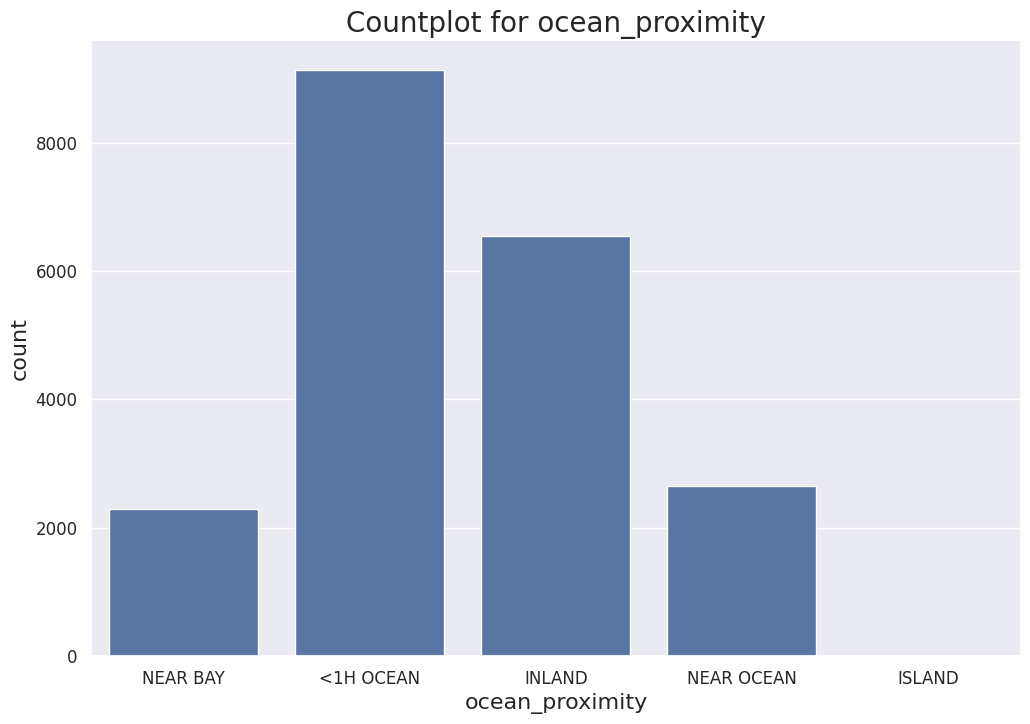

In [ ]:
# Countplot in Categorical Columns:

for cat in cat_cols:
  sns.countplot(data=df, x=cat)
  plt.title(f"Countplot for {cat}")
  plt.show()

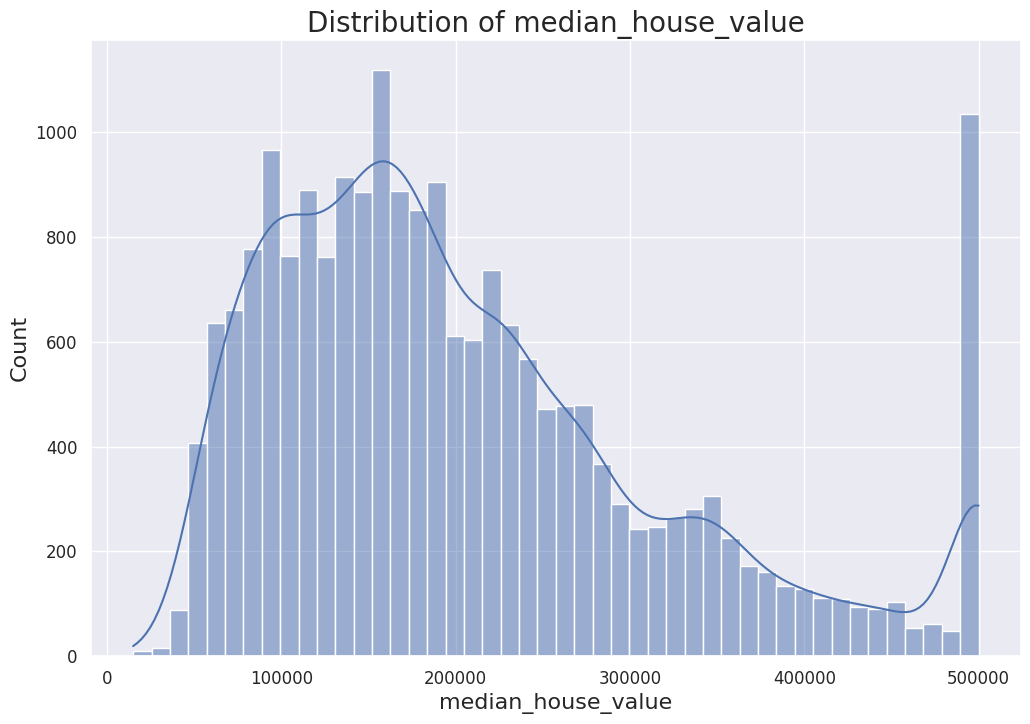

In [ ]:
# Target Column Distribution
sns.histplot(data=df, x=TARGET_COL, kde=True)
plt.title(f"Distribution of {TARGET_COL}")
plt.show()

In [ ]:
df[TARGET_COL].value_counts()

,count
median_house_value,
500001.000,965
137500.000,122
162500.000,117
112500.000,103
187500.000,93
...,...
34200.000,1
46200.000,1
352000.000,1


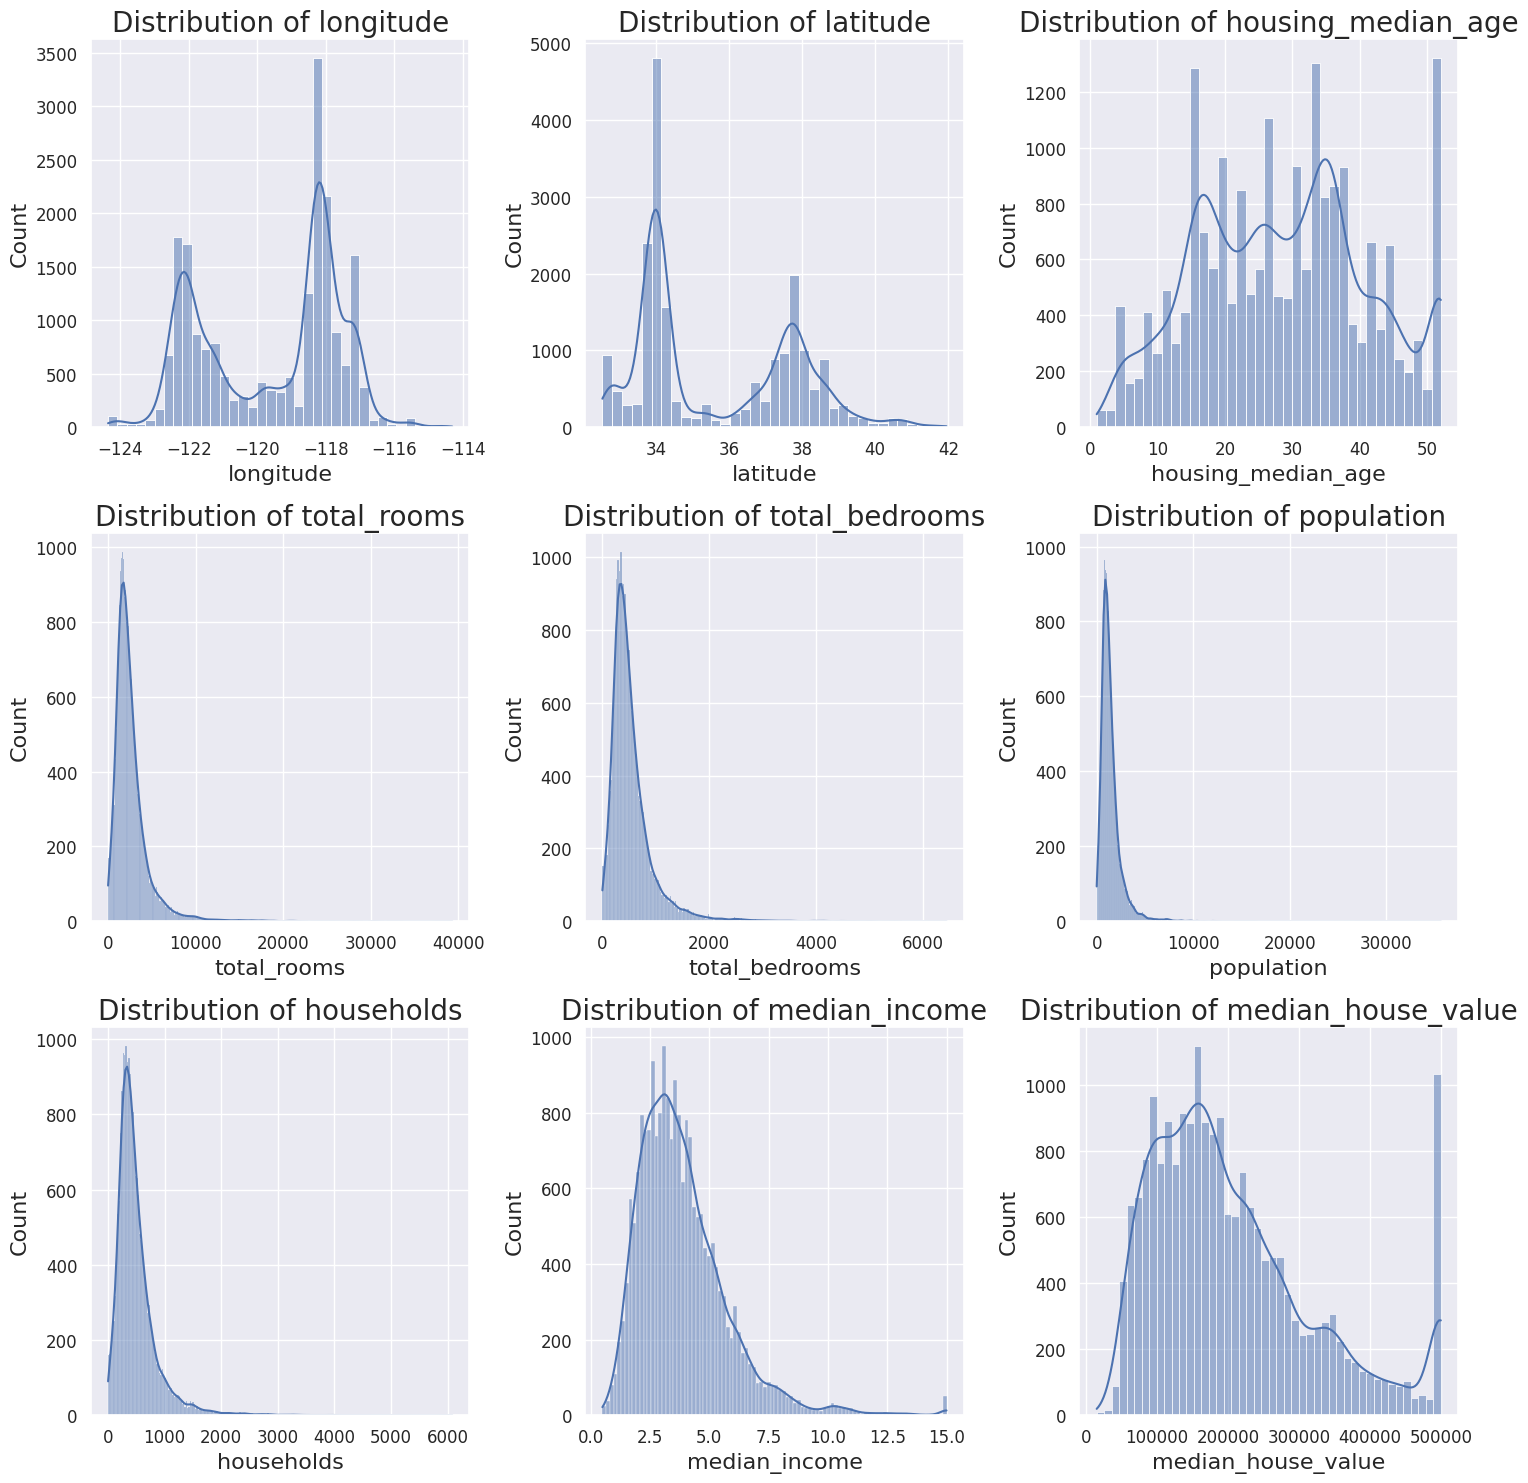

In [ ]:
# Histogram plot - distribution

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  sns.histplot(data=df, x=col, kde=True, ax=axes[i])
  axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

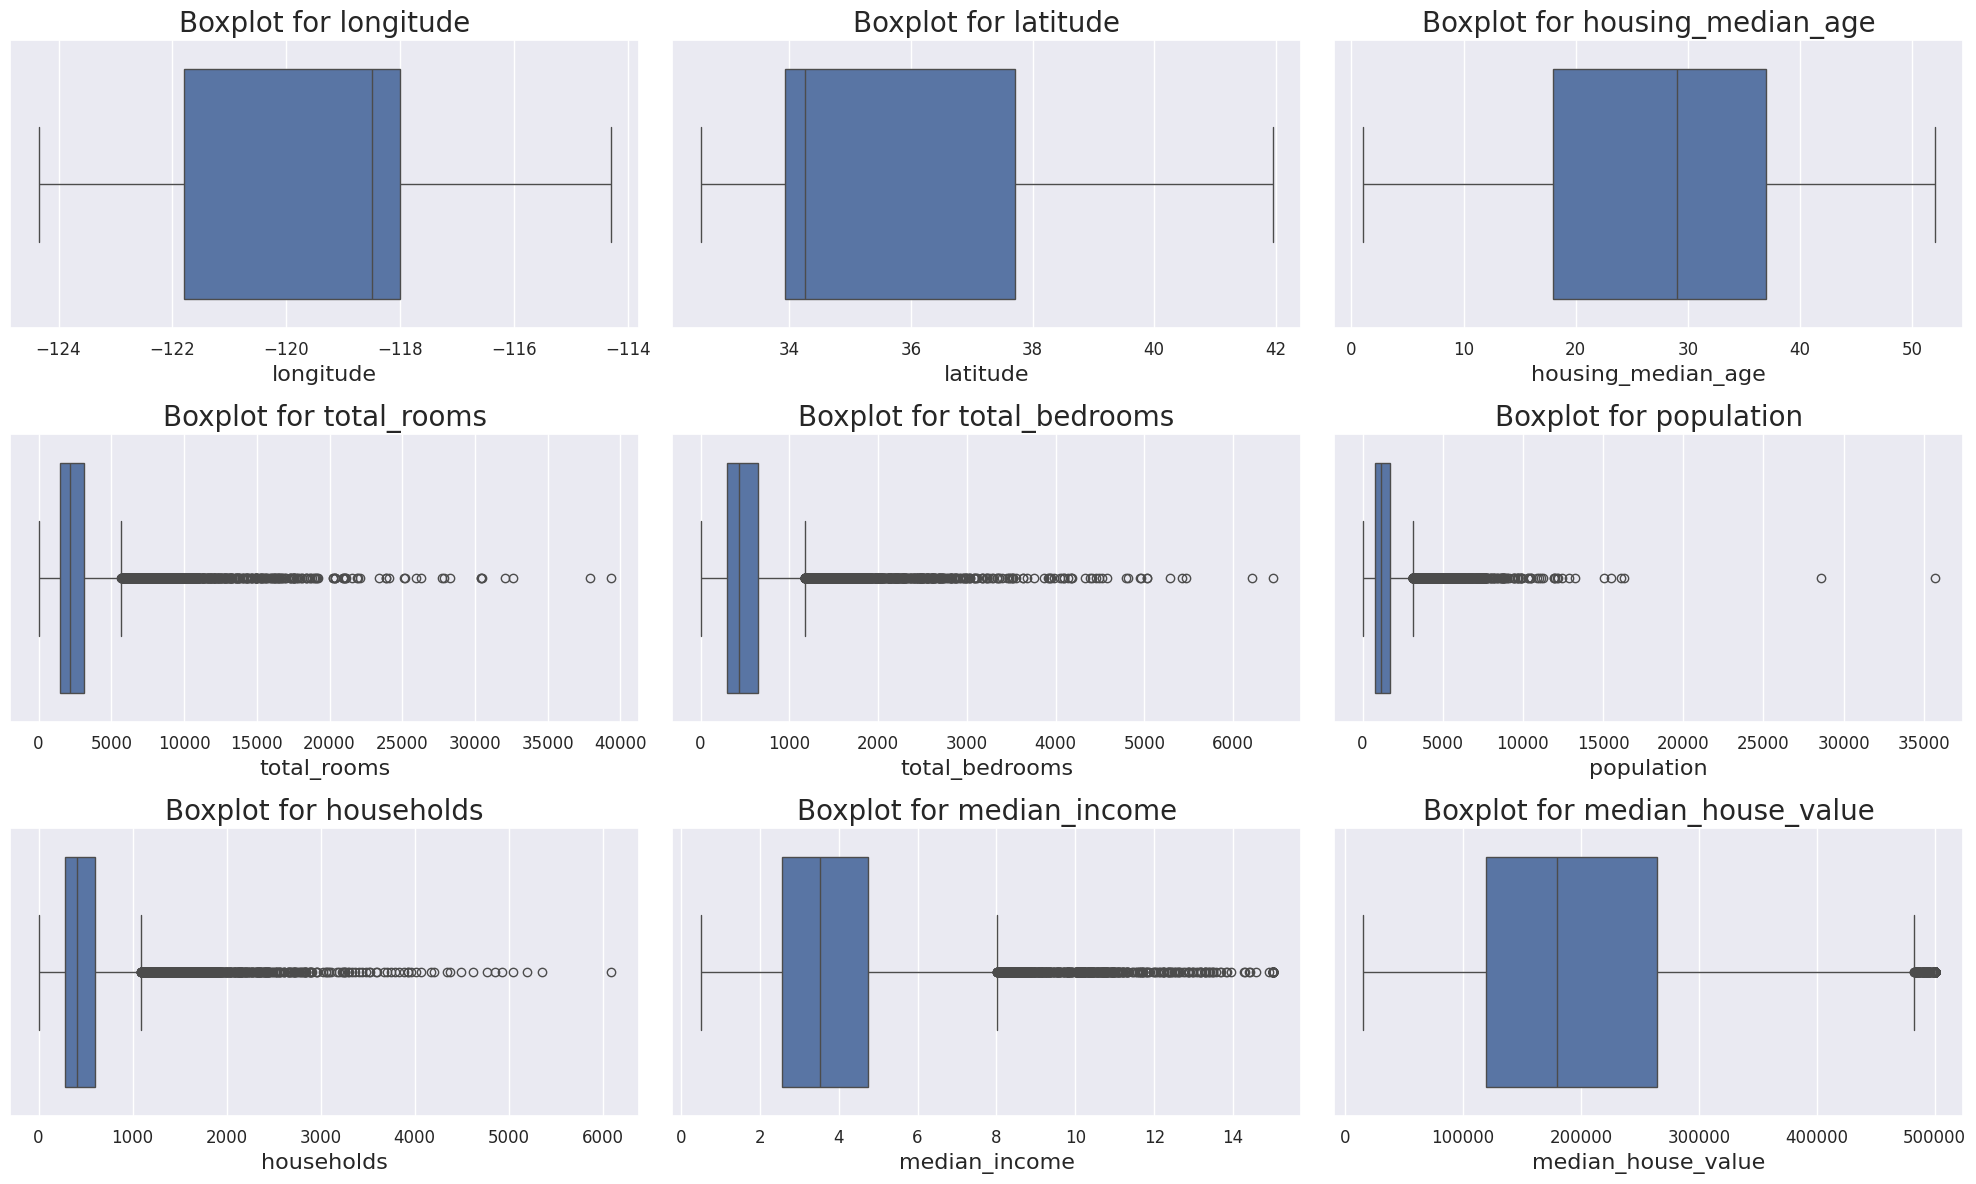

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(20,12))
axes = axes.flatten()

for i,col in enumerate(num_cols):
  sns.boxplot(data=df, x=col, ax=axes[i])
  axes[i].set_title(f"Boxplot for {col}")

plt.tight_layout()
plt.show()

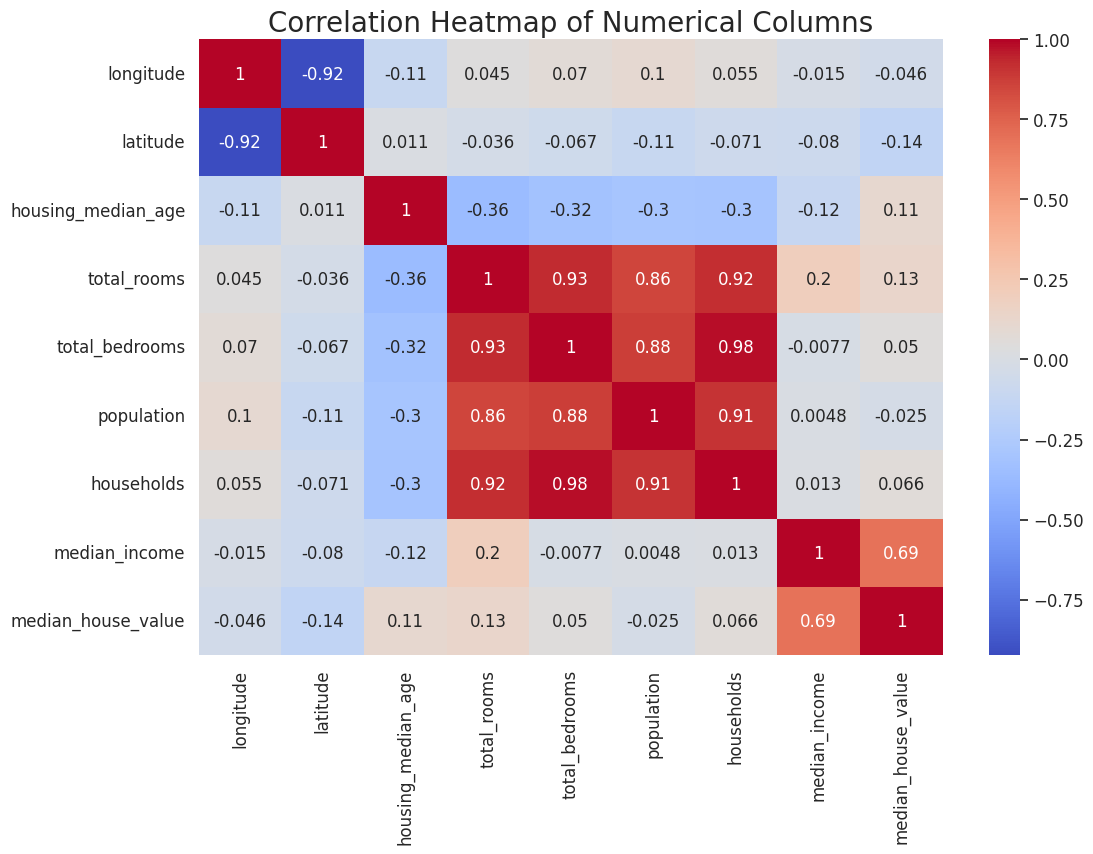

In [ ]:
# identify presence of highly correlated columns & feature relationships

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

In [ ]:
# Corelation with Target Column

corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("Correlation with target:\n")
print(corr_with_target)

Correlation with target:

median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


**Key Insights from EDA:**
1. Dataset has numeric + categorical columns(ocean_proximity)
2. Only total_bedrooms has missing values.
3. Target column median_house_value is right skewed and has been capped at 500000 dollars.
4. Several features show strong right skew and outliers(but it is alright to have so for those features).
5. median_income column is the strongest predictor.
5. High multicollinearity between population, households, total_rooms and total_bedrooms.

**Preprocessing & Evaluation Plan:**
1. Median imputation for missing values
2. One-hot encoding for categorical feature
3. Feature scaling for linear models
4. Use pipelines to avoid data leakage
5. Baseline model → CV model selection → hyperparameter tuning
6. Primary metric: RMSE, secondary: MAE and R²
7. Final evaluation only on test set

**4. Data Preprocessing**

In [ ]:
# separate features and target

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [ ]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [ ]:
y.head()

,median_house_value
0,452600.000
1,358500.000
2,352100.000
3,341300.000
4,342200.000


In [ ]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
#

In [ ]:
print("Train shape:", X_train.shape)

print("Test shape:", X_test.shape)

Train shape: (16512, 9)
Test shape: (4128, 9)


**Preprocessing Pipeline**

In [ ]:
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# numerical features - preprocessing steps
numerical_transformer = Pipeline(steps=[("simple_imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])

# categorical features - preprocessing steps
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))])

# Preprocessing Pipeline
preprocess = ColumnTransformer(transformers=[("num", numerical_transformer, numerical_features), ("cat", categorical_transformer, categorical_features)])
#

Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


**5. Baseline model (No CV, No Tuning)**

In [ ]:
# preprocess the model and train the baseline model'
base_model  = Pipeline(steps=[("preprocess", preprocess), ("model", LinearRegression())])

In [ ]:
base_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

**Evaluation of Baseline Model**

In [ ]:
train_baseline_pred = base_model.predict(X_train)

test_baseline_pred = base_model.predict(X_test)

In [ ]:
train_baseline_pred[:5]

array([188628.0772436 , 290379.8948687 , 250985.48476349, 146878.07878194,
       165789.41368924])

In [ ]:
y_train[:5]

,median_house_value
14196,103000.000
8267,382100.000
17445,172600.000
14265,93400.000
2271,96500.000


In [ ]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n=== TRAIN BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE : {train_baseline_mae:.3f}")
print(f"R2  : {train_baseline_r2:.3f}")
#


=== TRAIN BASELINE METRICS (LinearRegression) ===
RMSE: 68433.937
MAE : 49594.842
R2  : 0.650


In [ ]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n=== TEST BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"R2  : {test_baseline_r2:.3f}")



=== TEST BASELINE METRICS (LinearRegression) ===
RMSE: 70059.193
MAE : 50670.489
R2  : 0.625


**6. Model Selection & Optimization**

In [ ]:
k=5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
scoring = {
    "RMSE" : "neg_root_mean_squared_error",
    "MAE" : "neg_mean_absolute_error",
    "R2" : "r2"
}

In [ ]:
rows = []

# Redefine the model dictionary to ensure it's correctly initialized
model = {
    "Linear Regression" : LinearRegression(),
    "Ridge" : Ridge(random_state=RANDOM_STATE),
    "Lasso" : Lasso(random_state=RANDOM_STATE, max_iter=100000),
    "Random Forest" : RandomForestRegressor(),
    "Hist Gradient Boosting" : HistGradientBoostingRegressor()
}

for name, model_instance in model.items():
  pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model_instance)])
  cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)

  rows.append({
      "Model" : name, "cv_rmse" : -cv_results['test_RMSE'].mean(), "cv_mae" : -cv_results["test_MAE"].mean(), "cv_r2score" : cv_results["test_R2"].mean()})
# sort based on lowest rmse value
cv_final_results = pd.DataFrame(rows).sort_values("cv_rmse",ascending=True)
print("=== CV Model Comparison ===")
print(cv_final_results)

=== CV Model Comparison ===
                    Model   cv_rmse    cv_mae  cv_r2score
4  Hist Gradient Boosting 48080.490 32237.716       0.827
3           Random Forest 49433.715 32283.046       0.817
1                   Ridge 68595.617 49664.331       0.648
2                   Lasso 68603.233 49667.263       0.648
0       Linear Regression 68604.163 49667.159       0.648


In [ ]:
best_rows = cv_final_results.iloc[0]
best_rows
#

,4
Model,Hist Gradient Boosting
cv_rmse,48080.490
cv_mae,32237.716
cv_r2score,0.827


In [ ]:
best_model_name  = best_rows["Model"]
best_model = model[best_model_name]
best_rmse = best_rows["cv_rmse"]

print("Best model based on CV RMSE:")
print("Model :", best_model_name)
print("CV RMSE:", best_rmse)

Best model based on CV RMSE:
Model : Hist Gradient Boosting
CV RMSE: 48080.490369112405


**BEST MODEL: HistGradientBoostingRegressor**

**7. Hyperparameter Tuning**

In [ ]:
hgb_pipe = Pipeline(steps=[('preprocess', preprocess), ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))])

In [ ]:
param_grid = {
    "model__learning_rate" : [0.01,0.2,0.3],
    "model__max_depth"  :    [None,3,6],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0]
    }

In [ ]:
grid_search = GridSearchCV(estimator=hgb_pipe,
                           param_grid=param_grid,
                           cv=cv,
                           scoring="neg_root_mean_squared_error", # Use RMSE as the primary scoring metric
                           n_jobs=-1,
                           verbose=2)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simple_imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('model',
                                        HistGradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__l2_regularization': [0.0, 0.1, 1.0],
                         'model__learning_rate': [0.01, 0.2, 0.3],
                         'model__max_depth': [None, 3, 6],
                         'model__max_leaf_nodes': [15, 31, 63],
                         'model__min_samples_leaf': [20, 50, 100]},
             scoring='neg_root_mean_squared_error', verbose=2)

### Best Parameters and Score

In [ ]:
print("Best parameters found: ", grid_search.best_params_)
print("Best RMSE found: ", -grid_search.best_score_)


Best parameters found:  {'model__l2_regularization': 1.0, 'model__learning_rate': 0.2, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}
Best RMSE found:  47546.141044337746


**8. Retraining with best params**

In [ ]:
hgb_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(
            l2_regularization=1,
            learning_rate=0.2,
            max_depth=None,
            max_leaf_nodes=63,
            min_samples_leaf=20
        ))
    ]
)

In [ ]:
# train best model on entire training data (can also be done with refit=True in grid search)
hgb_best.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=1,
                                               learning_rate=0.2,
                                               max_leaf_nodes=63))])

**9. Final Evaluation**

In [ ]:
test_best_pred = hgb_best.predict(X_test)

test_best_rmse = root_mean_squared_error(y_test, test_best_pred)
test_best_mae = mean_absolute_error(y_test, test_best_pred)
test_best_r2 = r2_score(y_test, test_best_pred)

print("\n=== TEST BEST MODEL METRICS (HistGradientBoostingRegressor) ===")
print(f"RMSE: {test_best_rmse:.3f}")
print(f"MAE : {test_best_mae:.3f}")
print(f"R2  : {test_best_r2:.3f}")


=== TEST BEST MODEL METRICS (HistGradientBoostingRegressor) ===
RMSE: 46750.970
MAE : 30815.235
R2  : 0.833


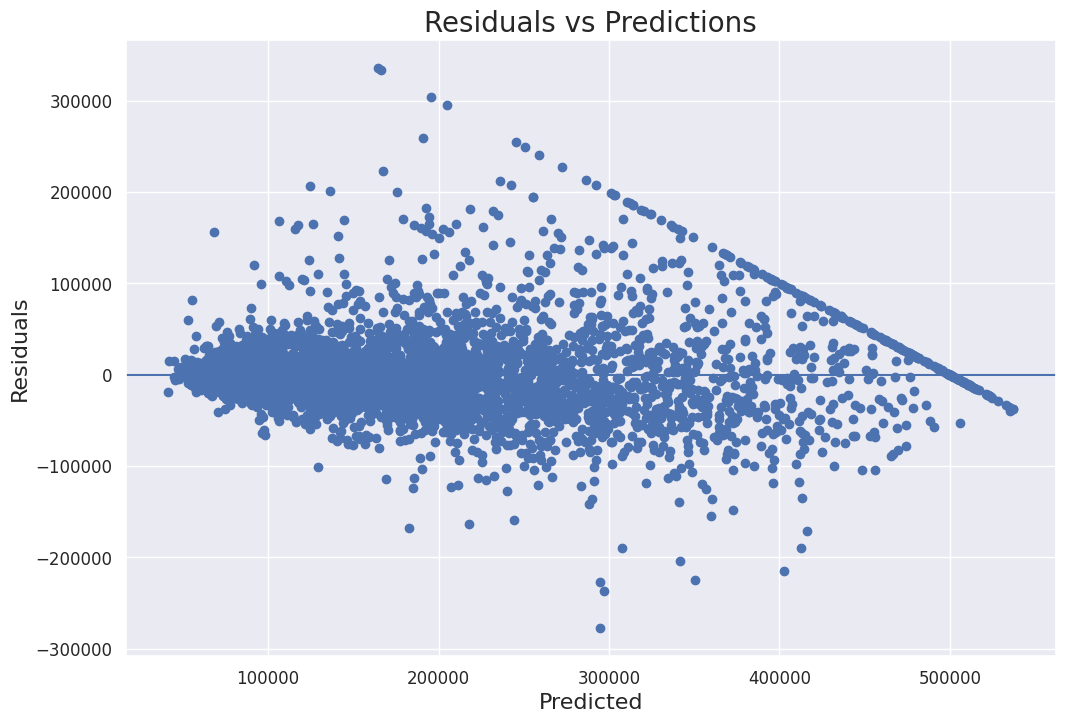

In [ ]:
# Residual plots

y_residual = y_test - test_best_pred
plt.scatter(test_best_pred, y_residual,s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()


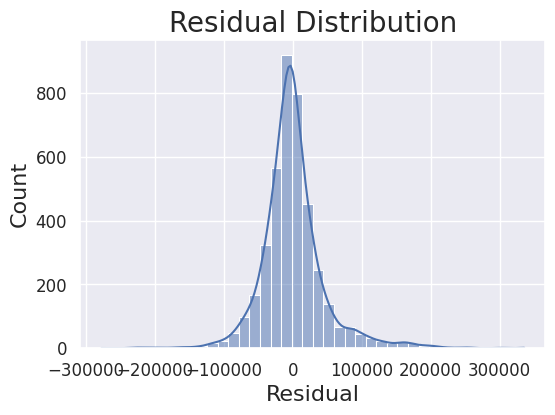

In [ ]:

plt.figure(figsize=(6, 4))
sns.histplot(y_residual, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

**10. Building a Predictive System**

In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
def predict_house_price(
    model,
    longitude: float,
    latitude: float,
    housing_median_age: float,
    total_rooms: float,
    total_bedrooms: float,
    population: float,
    households: float,
    median_income: float,
    ocean_proximity: str
) -> float:
    """
    Predict median_house_value for one new house.
    total_bedrooms can be np.nan (pipeline will impute).
    """
    new_row = pd.DataFrame([{
        "longitude": longitude,
        "latitude": latitude,
        "housing_median_age": housing_median_age,
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": households,
        "median_income": median_income,
        "ocean_proximity": ocean_proximity
    }])

    return float(model.predict(new_row)[0])

In [ ]:
# Example inference
example_pred = predict_house_price(
    model=hgb_best,
    longitude=-122.230,
    latitude=37.880,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=200, # Added total_bedrooms
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
 )

print("\nExample prediction:", example_pred)


Example prediction: 457589.1278037709
